# Using Numerical Priors

This tutorial demonstrates how to use `radvel.prior.NumericalPrior` to incorporate constraints from external analyses (e.g., transit photometry) into a radial velocity fit.

A common scenario: transit fitting provides posterior distributions on orbital period and time of conjunction. Rather than summarizing these as simple Gaussians, `NumericalPrior` preserves the full shape of the external posterior using kernel density estimation (KDE).

We will:
1. Generate synthetic RV data for a single-planet system
2. Simulate posterior samples as they might come from a transit fit
3. Apply them as `NumericalPrior` constraints on the RV fit
4. Run MAP fitting and MCMC sampling

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import corner

import radvel
import radvel.likelihood
import radvel.posterior
import radvel.prior
import radvel.fitting

/Users/bfulton/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Generate Synthetic RV Data

Set up a single-planet Keplerian model and generate noisy RV observations.

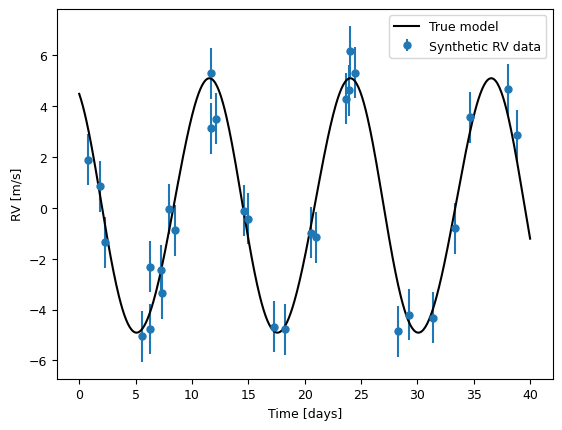

In [2]:
np.random.seed(42)

# True orbital parameters
params_true = radvel.Parameters(1, basis='per tc secosw sesinw k')
params_true['per1'] = radvel.Parameter(value=12.5)
params_true['tc1'] = radvel.Parameter(value=2.0)
params_true['secosw1'] = radvel.Parameter(value=0.1)
params_true['sesinw1'] = radvel.Parameter(value=0.15)
params_true['k1'] = radvel.Parameter(value=5.0)
params_true['dvdt'] = radvel.Parameter(value=0.0, vary=False)
params_true['curv'] = radvel.Parameter(value=0.0, vary=False)

rv_mod_true = radvel.RVModel(params_true)

# Generate observations spanning ~3 orbits
t = np.sort(np.random.uniform(0, 40, 30))
errvel = np.zeros(t.size) + 1.0
syn_rv = rv_mod_true(t) + np.random.randn(t.size) * errvel

# Plot
ti = np.linspace(0, 40, 500)
plt.errorbar(t, syn_rv, yerr=errvel, fmt='o', label='Synthetic RV data')
plt.plot(ti, rv_mod_true(ti), 'k-', label='True model')
plt.xlabel('Time [days]')
plt.ylabel('RV [m/s]')
plt.legend()
plt.show()

## Simulate External Posterior Samples

In practice, you would obtain posterior samples from fitting transit photometry
(e.g., with `batman`, `exoplanet`, or `juliet`). Here we simulate that output
by drawing samples from distributions centered on the true period and time of
conjunction.

We add a slight skew to the period posterior to illustrate that `NumericalPrior`
captures non-Gaussian shapes that a simple Gaussian prior would miss.

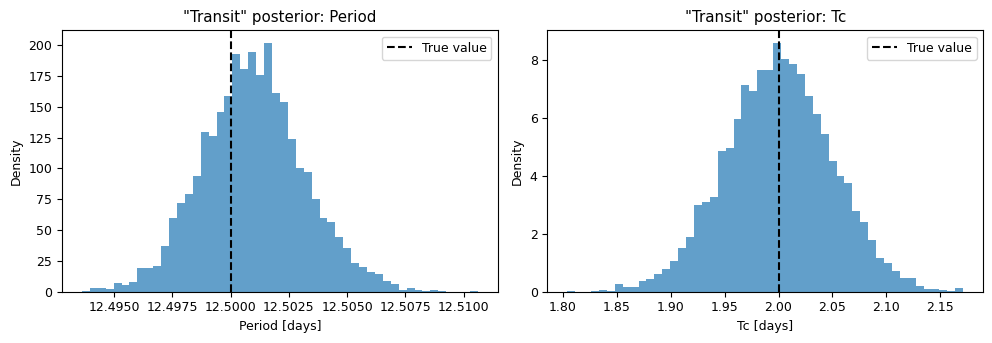

In [3]:
nsamples = 5000

# Simulate a slightly skewed period posterior from transit fitting
per_samples = 12.5 + 0.002 * np.random.randn(nsamples) + 0.001 * np.random.exponential(1, nsamples)

# Simulate a tc posterior from transit fitting
tc_samples = 2.0 + 0.05 * np.random.randn(nsamples)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(per_samples, bins=50, density=True, alpha=0.7)
axes[0].axvline(12.5, color='k', ls='--', label='True value')
axes[0].set_xlabel('Period [days]')
axes[0].set_ylabel('Density')
axes[0].set_title('"Transit" posterior: Period')
axes[0].legend()

axes[1].hist(tc_samples, bins=50, density=True, alpha=0.7)
axes[1].axvline(2.0, color='k', ls='--', label='True value')
axes[1].set_xlabel('Tc [days]')
axes[1].set_ylabel('Density')
axes[1].set_title('"Transit" posterior: Tc')
axes[1].legend()

plt.tight_layout()
plt.show()

## Create NumericalPrior Objects

`NumericalPrior` takes a list of parameter names and an array of posterior samples.
It uses `scipy.stats.gaussian_kde` internally to estimate the probability density.

For large sample arrays, consider thinning to improve performance.

In [4]:
prior_per = radvel.prior.NumericalPrior(['per1'], per_samples)
prior_tc = radvel.prior.NumericalPrior(['tc1'], tc_samples)

print(prior_per)
print(prior_tc)

Numerical prior on $P_{b}$, defined using Gaussian kernel density estimation.
Numerical prior on $T\rm{conj}_{b}$, defined using Gaussian kernel density estimation.


## Set Up the RV Fit with Numerical Priors

Create a likelihood and posterior, then attach the numerical priors.
We initialize `per1` and `tc1` at the median of the transit posteriors.

In [5]:
# Initialize model using the transit-derived values as starting point.
# In practice, you would use the median of your transit posteriors.
params = radvel.Parameters(1, basis='per tc secosw sesinw k')
params['per1'] = radvel.Parameter(value=np.median(per_samples))
params['tc1'] = radvel.Parameter(value=np.median(tc_samples))
params['secosw1'] = radvel.Parameter(value=0.05)
params['sesinw1'] = radvel.Parameter(value=0.05)
params['k1'] = radvel.Parameter(value=4.0)
params['dvdt'] = radvel.Parameter(value=0.0, vary=False)
params['curv'] = radvel.Parameter(value=0.0, vary=False)

rv_mod = radvel.RVModel(params)

like = radvel.likelihood.RVLikelihood(rv_mod, t, syn_rv, errvel)
like.params['gamma'] = radvel.Parameter(value=0.0)
like.params['jit'] = radvel.Parameter(value=1.0)

post = radvel.posterior.Posterior(like)

# Add numerical priors from "transit" posteriors
post.priors += [prior_per, prior_tc]

# Standard priors on other parameters
post.priors += [radvel.prior.EccentricityPrior(1)]
post.priors += [radvel.prior.HardBounds('jit', 0.0, 10.0)]

print(post)

parameter                     value      vary
per1                        12.5009       True
tc1                         2.00043       True
secosw1                        0.05       True
sesinw1                        0.05       True
k1                                4       True
dvdt                              0      False
curv                              0      False
gamma                             0       True
jit                               1       True
tp1                        0.451846           
e1                            0.005           
w1                         0.785398           

Priors
------
Numerical prior on ['per1']
Numerical prior on ['tc1']
e1 constrained to be < 0.99
Bounded prior on jit, min=0.0, max=10.0



## MAP Fit

Initial loglikelihood = -42.820551
Performing maximum a posteriori fit...


divide by zero encountered in log


Final loglikelihood = -34.298635
Best-fit parameters:
parameter                     value      vary
per1                         12.501       True
tc1                         2.00617       True
secosw1                    0.127663       True
sesinw1                    0.259058       True
k1                          4.88433       True
dvdt                              0      False
curv                              0      False
gamma                     -0.216222       True
jit                     1.40869e-09       True
tp1                         1.23403           
e1                        0.0834089           
w1                          1.11293           

Priors
------
Numerical prior on ['per1']
Numerical prior on ['tc1']
e1 constrained to be < 0.99
Bounded prior on jit, min=0.0, max=10.0



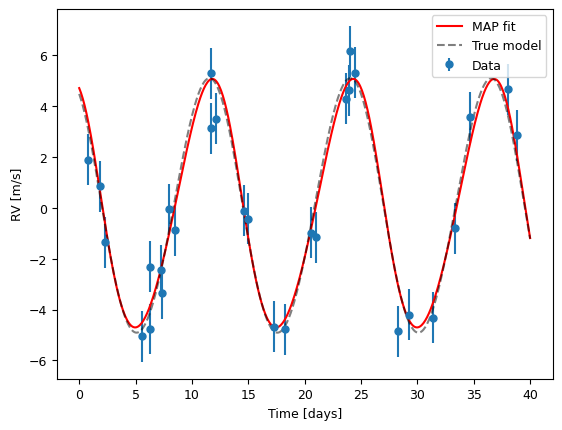

In [6]:
post = radvel.fitting.maxlike_fitting(post)

plt.errorbar(t, syn_rv, yerr=errvel, fmt='o', label='Data')
plt.plot(ti, post.likelihood.model(ti), 'r-', label='MAP fit')
plt.plot(ti, rv_mod_true(ti), 'k--', alpha=0.5, label='True model')
plt.xlabel('Time [days]')
plt.ylabel('RV [m/s]')
plt.legend()
plt.show()

## MCMC Sampling

Run a short MCMC to sample the posterior. In practice you would run
longer chains (e.g., `nrun=10000`) with more ensembles for convergence.

In [7]:
df = radvel.mcmc(post, nwalkers=20, nrun=1000, ensembles=1)

1000/20000 (5.0%) steps complete; Running 568.81 steps/s; Mean acceptance rate = 50.6%; Min Auto Factor =   9; Max Auto Relative-Change =   inf; Min Tz = -1.0; Max G-R = 0.999
Discarding burn-in now that the chains are marginally well-mixed

20000/20000 (100.0%) steps complete; Running 1308.44 steps/s; Mean acceptance rate = 44.1%; Min Auto Factor =  14; Max Auto Relative-Change = 0.0449; Min Tz = -1.0; Max G-R = 1.000

MCMC: WARNING: chains did not pass convergence tests. They are likely not well-mixed.


## Results

The corner plot shows the posterior distributions. The tight constraints on
period and Tc come from the numerical priors (transit posteriors), while
the RV data constrain K, eccentricity, and the systemic velocity.

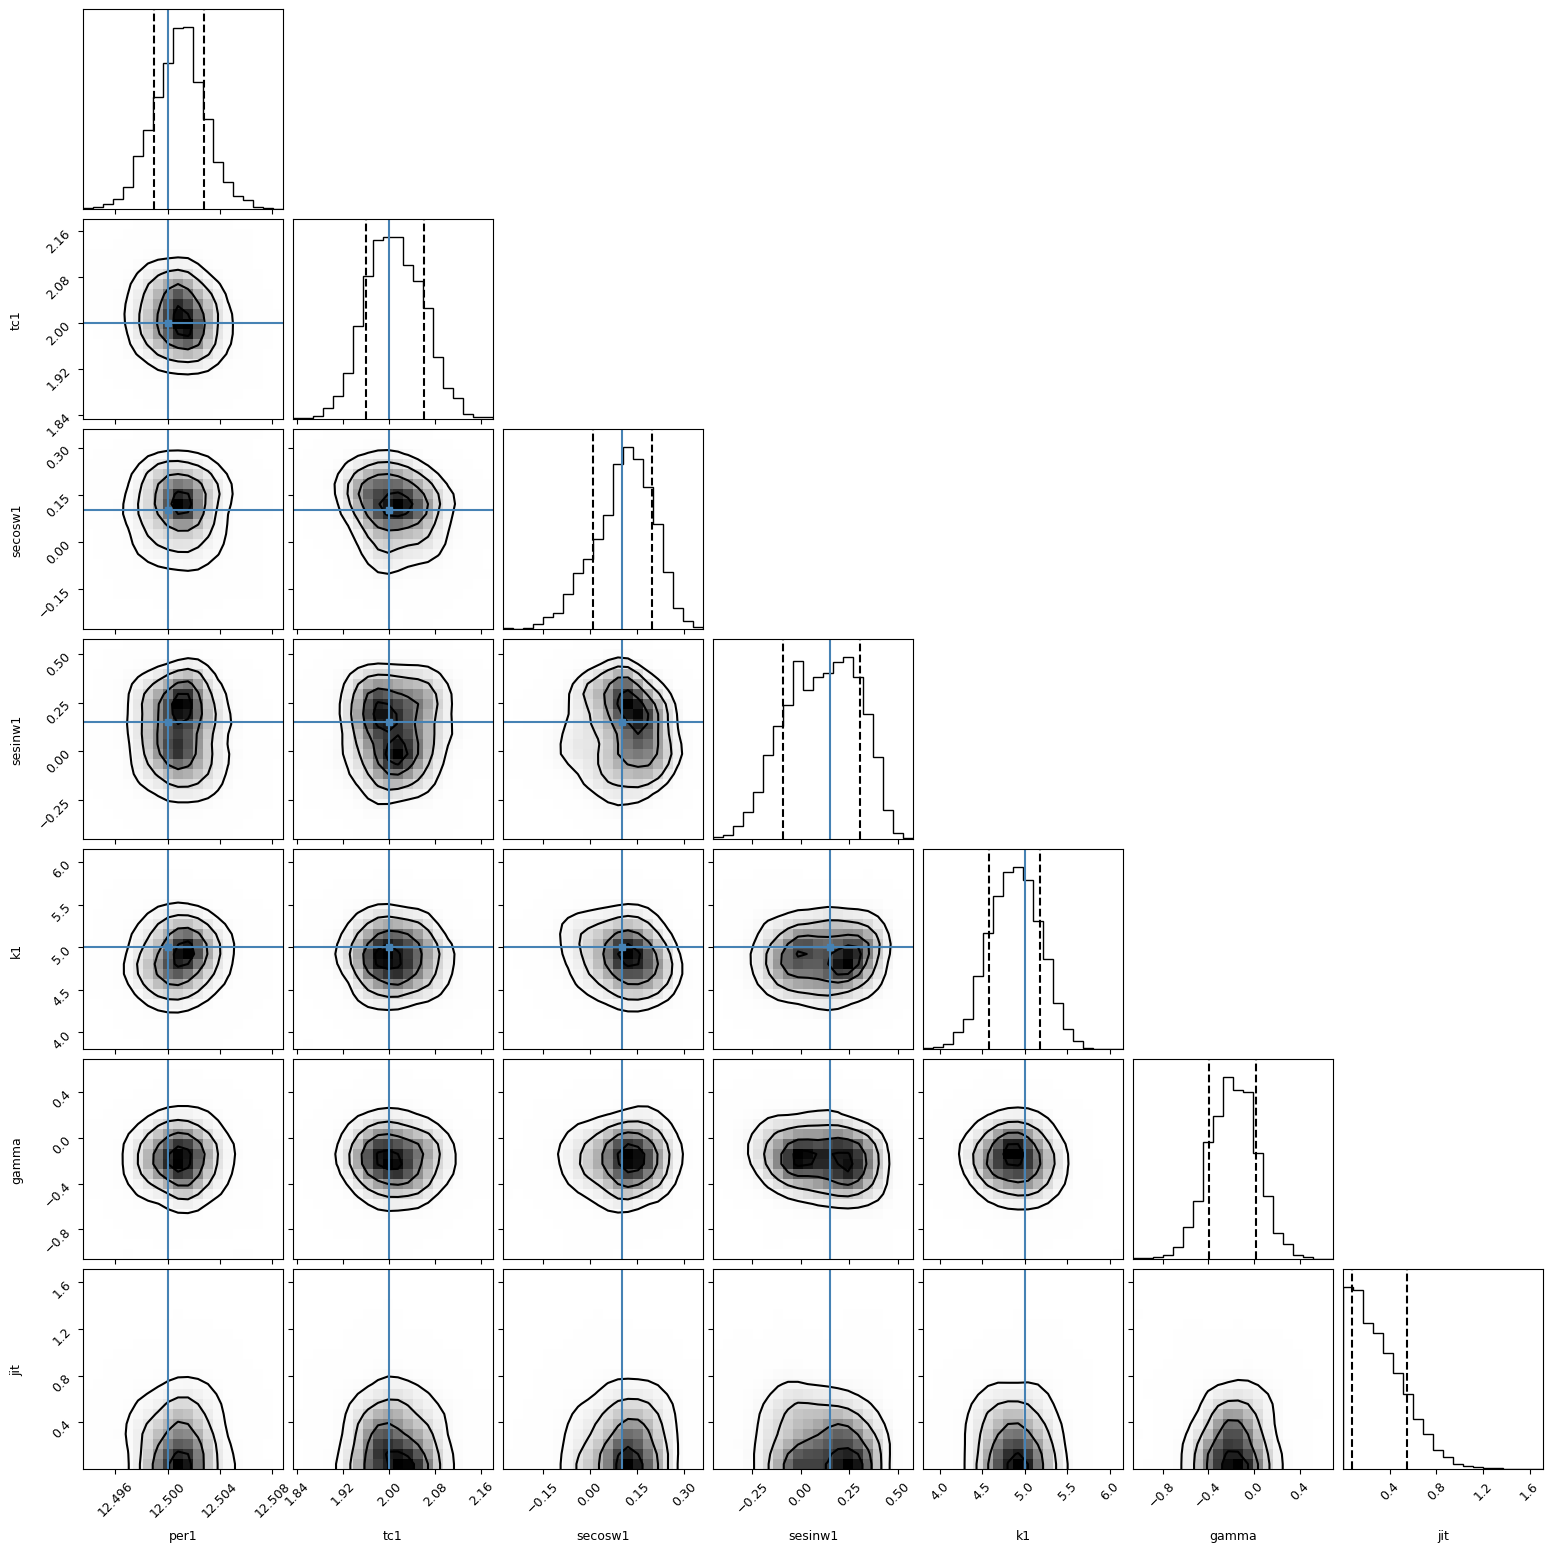

In [8]:
labels = [k for k in post.params.keys() if post.params[k].vary]
truths = [params_true[k].value if k in params_true else None for k in labels]

fig = corner.corner(
    df[labels],
    labels=labels,
    truths=truths,
    quantiles=[0.16, 0.84],
    plot_datapoints=False,
    smooth=True,
    bins=20
)
plt.show()

## Multivariate Numerical Priors

`NumericalPrior` also supports correlated (multivariate) priors. If your
external analysis produces correlated posteriors on multiple parameters,
pass them as a 2-D array with shape `(n_params, n_samples)`.

In [9]:
# Example: correlated period-Tc prior from a transit fit
joint_samples = np.vstack([per_samples, tc_samples])  # shape (2, nsamples)

prior_joint = radvel.prior.NumericalPrior(['per1', 'tc1'], joint_samples)
print(prior_joint)

Numerical prior on $P_{b}$ and $T\rm{conj}_{b}$, defined using Gaussian kernel density estimation.


This joint prior captures any covariance between period and Tc that a pair
of independent univariate priors would miss. Use whichever form best matches
the structure of your external constraints.